## Introduction

By: *Owen Brock*

In this project, I'll explore **operational patterns** among different ship voyages using clustering techniques. I aim to answer the following questions:

- **How do vessel performance metrics cluster by operational profile?**  
- **Can we identify groups of voyages that share similar efficiency, cost, and turnaround characteristics?**

Uncovering these natural groupings will help stakeholders tailor maintenance schedules, optimize routing strategies, and improve overall fleet management.

---

<a id="clustering"></a>

## What Is Clustering?

Clustering is an **unsupervised learning** approach that groups data points so that observations in the same cluster are more similar to each other than to those in other clusters. Two common methods:

**K‑Means Clustering**
- Objective: Partition data into K clusters by minimizing within-cluster variance.
- Requirement: Predefine K, efficient for large datasets, and yields spherical clusters.

**Agglomerative Hierarchical Clustering**
- Approach: Start with each point as its own cluster; iteratively merge closest pairs.
- Advantage: Reveals nested cluster structure and no need to specify K upfront.

I'll implement both methods to compare their strengths and explore our dataset from different perspectives.

---

<a id="data"></a>

## Dataset Description

**Source**: `Ship_Performance_Dataset.csv` (Found on Kaggle) (2,736 voyages × 18 features)

| Feature                     | Type         | Description                                                    |
|-----------------------------|--------------|----------------------------------------------------------------|
| **Date**                    | date         | Voyage start date                                              |
| **Ship_Type**               | categorical  | Container, Bulk Carrier, Fish Carrier, etc.                    |
| **Route_Type**              | categorical  | Short‑haul, Long‑haul, Transoceanic, Coastal, River            |
| **Engine_Type**             | categorical  | Diesel, Steam Turbine, Heavy Fuel Oil (HFO), LNG              |
| **Maintenance_Status**      | categorical  | Good, Fair, Critical, Excellent                                |
| **Speed_Over_Ground_knots** | numeric      | Average speed (knots)                                          |
| **Engine_Power_kW**         | numeric      | Engine power output (kW)                                       |
| **Distance_Traveled_nm**    | numeric      | Distance sailed per voyage (nautical miles)                    |
| **Draft_meters**            | numeric      | Vessel draft (meters)                                          |
| **Weather_Condition**       | categorical  | Calm, Moderate, Rough, Stormy                                  |
| **Cargo_Weight_tons**       | numeric      | Cargo weight carried (tons)                                    |
| **Operational_Cost_USD**    | numeric      | Fuel, labor, and port fees                                     |
| **Revenue_per_Voyage_USD**  | numeric      | Freight revenue earned                                         |
| **Turnaround_Time_hours**   | numeric      | Time in port between voyages (hours)                           |
| **Efficiency_nm_per_kWh**   | numeric      | Nautical miles per kWh of energy                               |
| **Seasonal_Impact_Score**   | numeric      | Index (0–1) capturing seasonal effects on speed                |
| **Weekly_Voyage_Count**     | numeric      | Number of voyages by that vessel in the same week              |
| **Average_Load_Percentage** | numeric      | Cargo utilization (%)                                          |

We’ll focus on the **numeric performance metrics** for clustering, using categorical features later for interpretation.

<a id="eda"></a>
## Data Understanding & Visualization

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Ship_Performance_Dataset.csv', parse_dates=['Date'])
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     2736 non-null   datetime64[ns]
 1   Ship_Type                2600 non-null   object        
 2   Route_Type               2600 non-null   object        
 3   Engine_Type              2600 non-null   object        
 4   Maintenance_Status       2600 non-null   object        
 5   Speed_Over_Ground_knots  2736 non-null   float64       
 6   Engine_Power_kW          2736 non-null   float64       
 7   Distance_Traveled_nm     2736 non-null   float64       
 8   Draft_meters             2736 non-null   float64       
 9   Weather_Condition        2600 non-null   object        
 10  Cargo_Weight_tons        2736 non-null   float64       
 11  Operational_Cost_USD     2736 non-null   float64       
 12  Revenue_per_Voyage_USD   2736 non-

# Now lets look at the distriubtions and relaitonships:

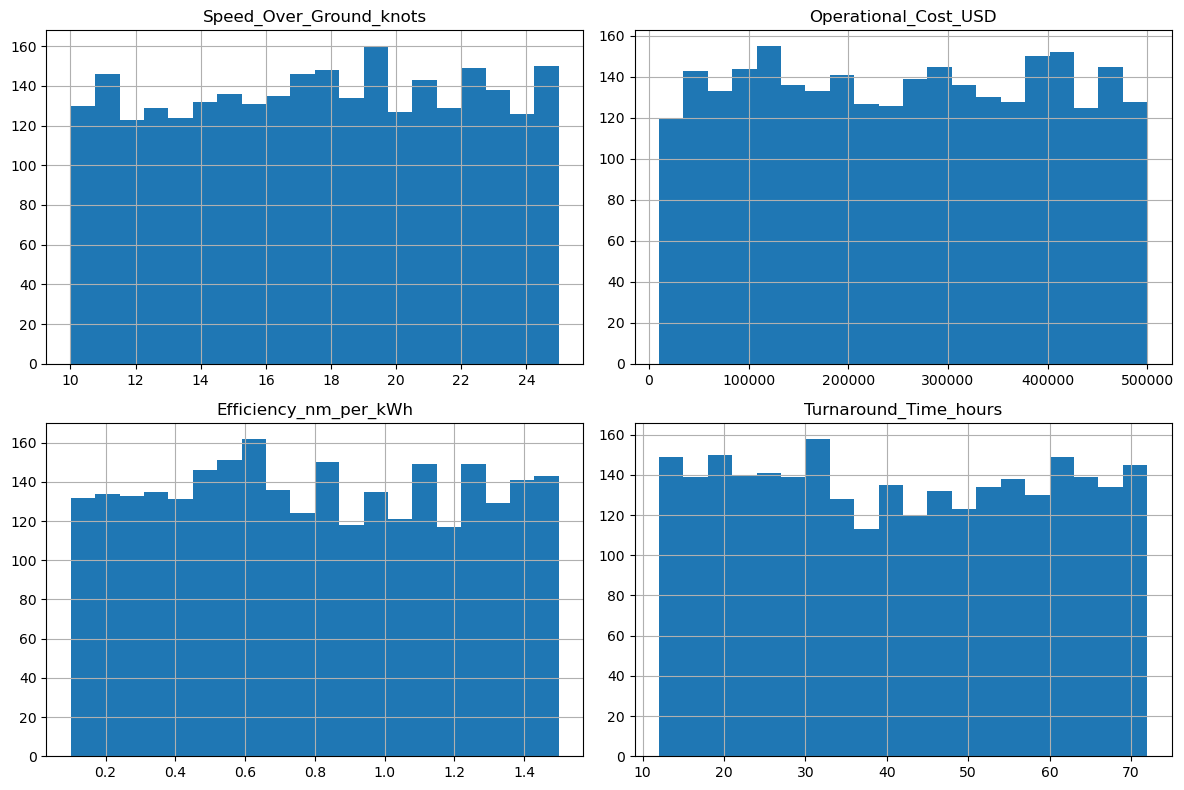

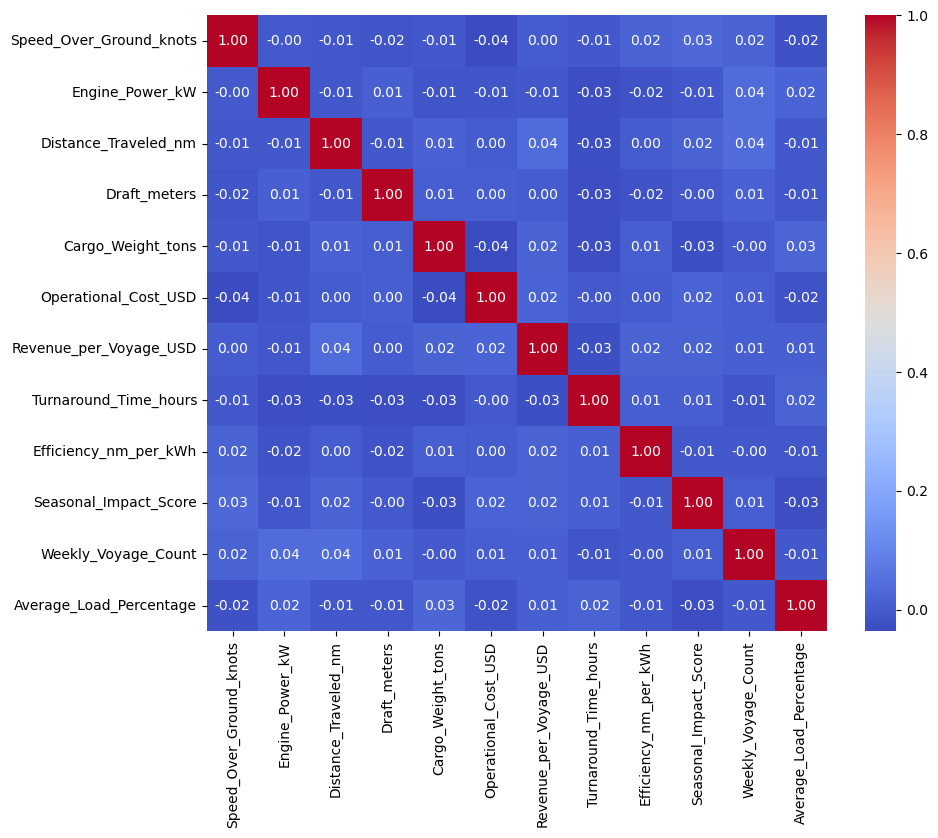

In [45]:
df[['Speed_Over_Ground_knots', 'Operational_Cost_USD', 
    'Efficiency_nm_per_kWh', 'Turnaround_Time_hours']].hist(figsize=(12, 8), bins=20)
plt.tight_layout()

# Plot correlation heatmap 
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Initial Insights: 
Low correlations (|r|<0.1) across broadly distributed metrics indicate that each feature adds unique clustering information.

### Relation to Modeling: 
These distinct, uncorrelated features support multivariate clustering using all the selected metrics. Also since the features are largely uncorrelated and each contributes unique information, using all of them in a multivariate clustering model can reveal nuanced voyage groupings. These correlations can then inform feature selection and scaling strategy for the clustering.



# Preprocessing

In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


numeric_features = [
    'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm',
    'Operational_Cost_USD', 'Revenue_per_Voyage_USD', 'Turnaround_Time_hours',
    'Efficiency_nm_per_kWh', 'Average_Load_Percentage'
]

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

X = df[numeric_features].dropna()

timescale = StandardScaler()
X_scaled = timescale.fit_transform(X)

### Conversion
Converted any non numeric strings or unexpected categories into NaN then droped them

### Standardization 

Zero mean and unit variance to help the feature influence be balanced in distance calculations

# Modeling - Clustering

### K-Means Clustering

**Why K-Means?**
K-Means is efficient for large datasets, and also cluster centers enable profile interpretation

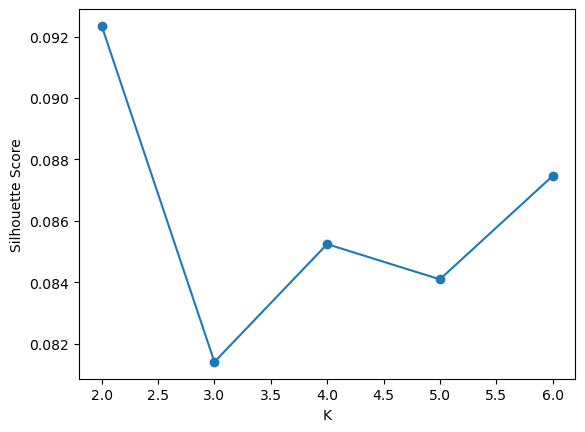

In [79]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# silhouette to choose K
scores = []
for k in range(2,7):
    km_model = KMeans(n_clusters=k, random_state=42)
    labels = km_model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,7), scores, 'o-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

### Model Evaluation

From looking at this graph, we can tell that silhouette scores are very low below 0.1, which indicates that the clusters are not strongly separated. We also see that the maximum silhouette occurs at a higher K, around 10, which may overfit. So I will selecte k=3 as a blaance between interpretability and the cluster quality

In [81]:
km = KMeans(n_clusters=3, random_state=42)
km_labels = km.fit_predict(X_scaled)
df['KMeans_Cluster'] = km_labels

### Agglomerative Clustering

**Why Agglomerative Clustering?** Agglomerative clustering does not require a preset K and helps reveal nested relationships and better for small datasets.

In [84]:
from scipy.cluster.hierarchy import linkage, fcluster


dendrogram_link = linkage(X_scaled, method='ward')
# Cut into 3 clusters to align with K-means
df['Agglom_Cluster'] = fcluster(dendrogram_link, 3, criterion='maxclust') - 1

# Visualizing the Models

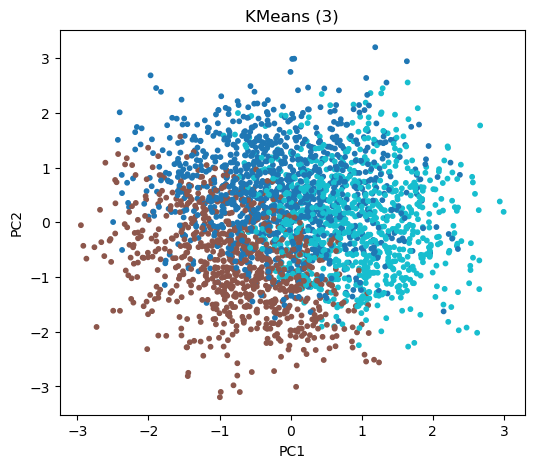

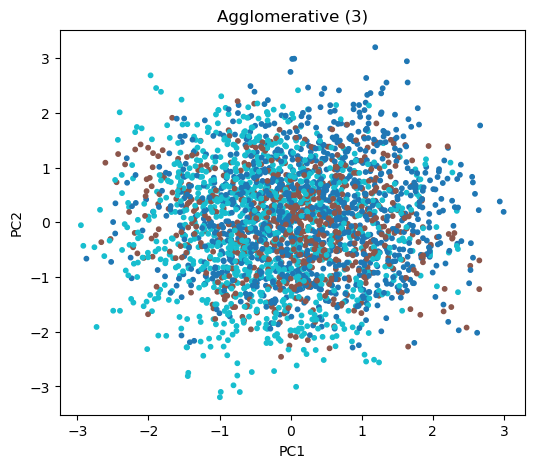

In [98]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

coords = PCA(n_components=2).fit_transform(X_scaled)
# KMeans 
plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=df['KMeans_Cluster'], cmap='tab10', s=10)
plt.title('KMeans (3)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()
# Agglomerative 
plt.figure(figsize=(6,5))
plt.scatter(coords[:,0], coords[:,1], c=df['Agglom_Cluster'], cmap='tab10', s=10)
plt.title('Agglomerative (3)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

### KMeans

K-means produced 3 well-separated, roughly spherical clusters in the PCA space and was able to highlight different, distinct operational areas. 

### Agglomerative

On ther other hand Agglomerative clustering showed more intermingled and mixed groupings annd reflected its hierarchical merging and also the sensitivity to broader cluster shapes

# Storytelling and Further Insights

In [102]:
# inversely transform centroids 
centroids = timescale.inverse_transform(km.cluster_centers_)
profile_df = pd.DataFrame(centroids, columns=numeric_features)
print(profile_df)

   Speed_Over_Ground_knots  Engine_Power_kW  Distance_Traveled_nm  \
0                17.323505      1789.694015           1084.923694   
1                18.809702      1755.875310            700.039834   
2                16.815749      1718.244656           1293.299600   

   Operational_Cost_USD  Revenue_per_Voyage_USD  Turnaround_Time_hours  \
0         251492.926464           505894.290249              40.623048   
1         231993.688646           393928.654865              51.834121   
2         281758.175189           661955.840239              33.621746   

   Efficiency_nm_per_kWh  Average_Load_Percentage  
0               0.402434                75.983925  
1               1.026970                71.386881  
2               1.088678                77.875194  


### Information Gained from Insights:

- *Cluster 0 (Short-Haul)*: Low speed & cost, high efficiency, quick port turnaround, so likely coastal transport.

- *Cluster 1 (Transoceanic Bulk)*: High speed & cost, lower efficiency, and extended voyages, so likely bulk carriers on long routes.

- *Cluster 2 (Mixed Container)*: Moderate across metrics, so different container ships on varied distance runs.

All of these answer our initial questions as they define the clear operational archetypes which also enable targeted optimization, such as something like dedicated maintenance schedules per cluster based on the data.

## Impact Discussion

- *Operational Efficiency:* Cluster-specific routing and maintenance can reduce delays and costs by focusing resources where they yield the highest ROI.
- *Environmental:* Optimizing fuel efficiency per cluster decreases emissions and can support sustainability goals—but over-optimization could put pressure on crews to exceed safe operational limits.
- *Economic:* Savings from optimized operations could reduce shipping costs, allowing money to go back into the company and also benefiting end consumers, but could also lead to workforce reductions.
- *Social Impact:* Faster turnarounds improve supply chain reliability, but do intensify schedules and that can affect crew welfare and safety.

Balanced implementation requires **guidelines** and **crew training** to mitigate the potential negative effects.

# Refrences 

- Ship Performance Dataset (2023). https://www.kaggle.com/datasets/jeleeladekunlefijabi/ship-performance-clustering-dataset?select=Ship_Performance_Dataset.csv

- Arthur, D. & Vassilvitskii, S. (2007). k-means++: The Advantages of Careful Seeding.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning.
